In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("data/train (1).csv")


In [3]:
df.columns


Index(['balcony_area', 'built_up_area', 'carpet_area', 'land_area',
       'distance_to_main_road', 'nearby_hospital_distance',
       'nearby_market_distance', 'nearby_metro_distance',
       'nearby_playground_distance', 'building_age', 'water_supply_hours',
       'year_built', 'maintenance_fee', 'property_tax', 'service_charge',
       'price', 'balconies', 'baths', 'beds', 'floor', 'number_of_units',
       'parking_spaces', 'total_floors', 'elevator', 'furnished',
       'gas_connection', 'generator', 'internet_available', 'power_backup',
       'security_guard', 'servant_room', 'road_width', 'facing_direction',
       'kitchen_type', 'locality', 'type'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   balcony_area                500 non-null    float64
 1   built_up_area               500 non-null    float64
 2   carpet_area                 500 non-null    float64
 3   land_area                   500 non-null    float64
 4   distance_to_main_road       500 non-null    float64
 5   nearby_hospital_distance    500 non-null    float64
 6   nearby_market_distance      500 non-null    float64
 7   nearby_metro_distance       500 non-null    float64
 8   nearby_playground_distance  500 non-null    float64
 9   building_age                500 non-null    float64
 10  water_supply_hours          500 non-null    float64
 11  year_built                  500 non-null    int64  
 12  maintenance_fee             500 non-null    float64
 13  property_tax                500 non-null    fl

In [5]:
X = df.drop(columns=['price'])
y = df['price']

In [6]:
X = pd.get_dummies(X, drop_first=True)

In [7]:
X_train,X_val,y_train,y_val = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [8]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train,y_train)

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 1)",[[17155678.07]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](69,)","['balcony_area','built_up_area','carpet_area',...,'type_townhouse', 'type_triplex','type_villa']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,69
n_outputs_ n_outputs_: intNumber of outputs.,int,1


In [9]:
y_predict = dummy.predict(X_val)

In [10]:
y_predict

array([17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 17155678.069775, 17155678.069775, 17155678.069775,
       17155678.069775, 1

In [11]:
mae = mean_absolute_error(y_val, y_predict)
mse = mean_squared_error(y_val,y_predict)
rmse = mse**0.5
r2_scoring = r2_score(y_val,y_predict)

In [12]:
print(mae)
print(mse)
print(rmse)
print(r2_scoring)

13303830.068141501
310295175169469.75
17615197.278755344
-0.002640550083532256


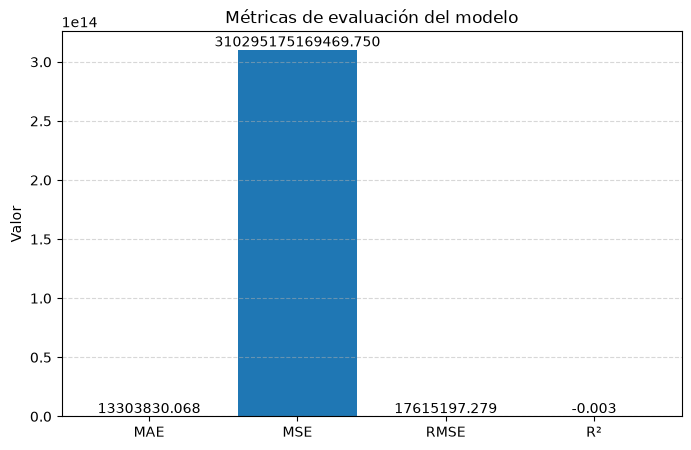

In [13]:

# Métricas
metricas = ['MAE', 'MSE', 'RMSE', 'R²']
valores = [mae, mse, rmse, r2_scoring]

# Crear figura
plt.figure(figsize=(8,5))
plt.bar(metricas, valores)

# Añadir etiquetas con los valores
for i, v in enumerate(valores):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')

plt.title('Métricas de evaluación del modelo')
plt.ylabel('Valor')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

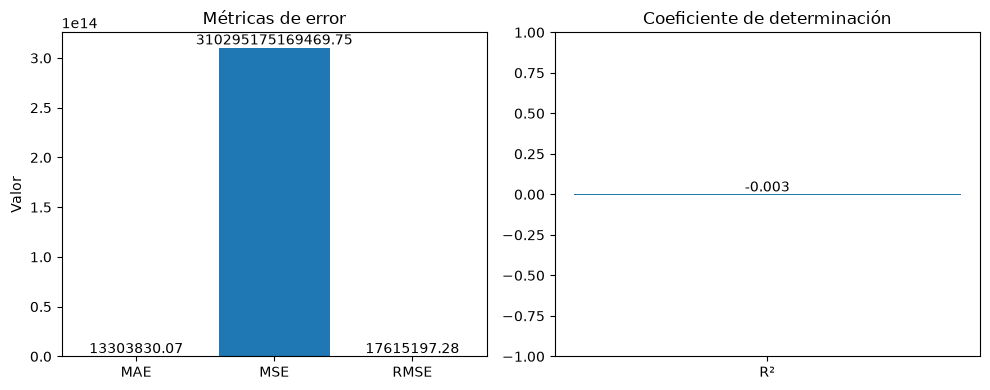

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Errores
errores = ['MAE', 'MSE', 'RMSE']
valores_error = [mae, mse, rmse]

ax[0].bar(errores, valores_error)
ax[0].set_title('Métricas de error')
ax[0].set_ylabel('Valor')

for i, v in enumerate(valores_error):
    ax[0].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# R²
ax[1].bar(['R²'], [r2_scoring])
ax[1].set_ylim(min(-1, r2_scoring-0.1), 1)
ax[1].set_title('Coeficiente de determinación')

ax[1].text(0, r2_scoring, f'{r2_scoring:.3f}',
           ha='center', va='bottom')

plt.tight_layout()
plt.show()

Para generar predicciones sobre el conjunto de prueba

In [15]:
test = pd.read_csv('data/test (1).csv')

In [16]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   balcony_area                500 non-null    float64
 1   built_up_area               500 non-null    float64
 2   carpet_area                 500 non-null    float64
 3   land_area                   500 non-null    float64
 4   distance_to_main_road       500 non-null    float64
 5   nearby_hospital_distance    500 non-null    float64
 6   nearby_market_distance      500 non-null    float64
 7   nearby_metro_distance       500 non-null    float64
 8   nearby_playground_distance  500 non-null    float64
 9   building_age                500 non-null    float64
 10  water_supply_hours          500 non-null    float64
 11  year_built                  500 non-null    int64  
 12  maintenance_fee             500 non-null    float64
 13  property_tax                500 non-null    fl

In [17]:
X_test = pd.get_dummies(test, drop_first=True)

In [18]:
X_test = X_test.reindex(X.columns, fill_value=0)

In [19]:
predictions = dummy.predict(X_test)

In [29]:
submission = pd.DataFrame({
    'ID': test['id'],
    'price': predictions
    })

ValueError: array length 69 does not match index length 500

In [ ]:
submission.to_csv('submission_dummy_levi.csv', index=False)

print(submission.head())

                       ID         price
0  <built-in function id>  1.715568e+07
1  <built-in function id>  1.715568e+07
2  <built-in function id>  1.715568e+07
3  <built-in function id>  1.715568e+07
4  <built-in function id>  1.715568e+07


In [30]:
test.columns

Index(['balcony_area', 'built_up_area', 'carpet_area', 'land_area',
       'distance_to_main_road', 'nearby_hospital_distance',
       'nearby_market_distance', 'nearby_metro_distance',
       'nearby_playground_distance', 'building_age', 'water_supply_hours',
       'year_built', 'maintenance_fee', 'property_tax', 'service_charge',
       'balconies', 'baths', 'beds', 'floor', 'number_of_units',
       'parking_spaces', 'total_floors', 'elevator', 'furnished',
       'gas_connection', 'generator', 'internet_available', 'power_backup',
       'security_guard', 'servant_room', 'road_width', 'facing_direction',
       'kitchen_type', 'locality', 'type', 'id'],
      dtype='str')

In [31]:
print(len(test))
print(len(predictions))
print(type(predictions))

500
69
<class 'numpy.ndarray'>


In [32]:
print(X.shape)
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(500, 69)
(400, 69)
(100, 69)
(69, 70)
